In [33]:
'''
the cat sat on the mat
RNN 계열 : 왼쪽에서 오른쪽, 단점 : 멀리 떨어진 단어들은 서로 영향을 주고 받기 어려움

The  cat that the boy who lived here adopted is sleeping
cat vs. sleeping

self-attention
Q: Query 찾고 싶은 정보
K: Knowledge 가진 정보
V: 최종 전달할 정보

비교대상                    유사도           의미
cat vs. the                낮음             the 의미 없음
cat vs. cat                높음             자기자신
cat vs. sat                중간             동사와 연결되어 행위를 나타냄
cat vs. on                 낮음             on 전치사...
cat vs. mat                낮음             의미적으로 멀다

softmax로 중요도 확률처럼 변경(유사도를 가중치로 변환)
단어                        가중치    
the                         0.05
cat                         0.06
sat                         0.3
mat                         0.05

cat이 보는 시점은
Query(cat) -> compare with -> key(the) -> key(cat) -> key(sat)

가중치
the : 0.1    cat : 0.7     sat : 0.2
출력 : 0.1 * value(the) + ... 

RNN 순차처리(왼->오) 가능
self-attention은 병렬처리가 가능

다중의미처리
river bank  river를 강하게 강조
bank loan   loan을 강하게 참조
'''

'\nthe cat sat on the mat\nRNN 계열 : 왼쪽에서 오른쪽, 단점 : 멀리 떨어진 단어들은 서로 영향을 주고 받기 어려움\n\nThe  cat that the boy who lived here adopted is sleeping\ncat vs. sleeping\n\nself-attention\nQ: Query 찾고 싶은 정보\nK: Knowledge 가진 정보\nV: 최종 전달할 정보\n\n비교대상                    유사도           의미\ncat vs. the                낮음             the 의미 없음\ncat vs. cat                높음             자기자신\ncat vs. sat                중간             동사와 연결되어 행위를 나타냄\ncat vs. on                 낮음             on 전치사...\ncat vs. mat                낮음             의미적으로 멀다\n\nsoftmax로 중요도 확률처럼 변경(유사도를 가중치로 변환)\n단어                        가중치    \nthe                         0.05\ncat                         0.06\nsat                         0.3\nmat                         0.05\n\ncat이 보는 시점은\nQuery(cat) -> compare with -> key(the) -> key(cat) -> key(sat)\n\n가중치\nthe : 0.1    cat : 0.7     sat : 0.2\n출력 : 0.1 * value(the) + ... \n\nRNN 순차처리(왼->오) 가능\nself-attention은 병렬처리가 가능\n\n다중의미처리\nriver bank  river를 강하게 강조\nbank loan   lo

Text(0, 0.5, 'query')

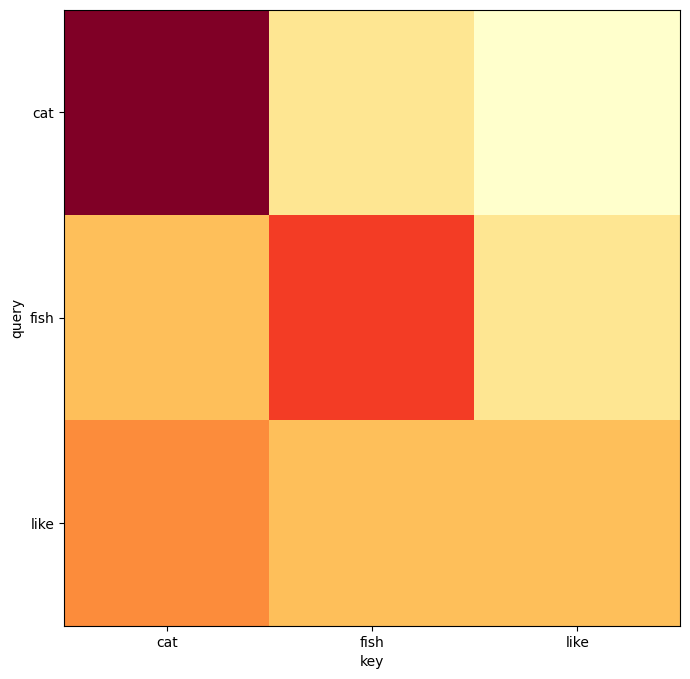

In [34]:
# self-attention 시각화
import numpy as np
import matplotlib.pyplot as plt

words = ['cat','fish','like']  # 고양이가 생선을 좋아한다
# 가상의 attention 가중치
# 각 행은 해당 단어가 다른단어들에게 주목하는 정도
attention_weight = np.array([
    [0.7,0.2,0.1],  # 고양이는 자가자신에게 가장 높은 가중치
    [0.3,0.5,0.2],  #
    [0.4,0.3,0.3]
])

fig, ax = plt.subplots(figsize=(10,8))
im = ax.imshow(attention_weight, cmap='YlOrRd')

ax.set_xticks(range(len(words)))
ax.set_yticks(range(len(words)))
ax.set_xticklabels(words)
ax.set_yticklabels(words)

ax.set_xlabel('key')
ax.set_ylabel('query')


In [35]:
# Beam Search
# 문장을 생성할 때 다음에 나올 단어는 수천~수만개가 될 수 있는데, 이걸 경우의 수로 따지면 답이 없음
# 상위 N개의 후보만 유지, N을 beam size
# beam size = 1 매번 가장 좋은 것만 선택(Greedy)
# beam size = 4 4개의 가능성을 동시에 탐색

In [36]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch
import time
MODEL_NAME = 't5-small'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

text = """summarize: The Amazon rainforest is the world's largest tropical rainforest.
  It covers much of northwestern Brazil and extends into Colombia, Peru and other South American countries.
  The Amazon is home to millions of species of plants and animals, many of which are found nowhere else on Earth.
  However, deforestation poses a significant threat to this vital ecosystem."""

print('원본 : ')
print(text.replace('summarize:',''))
inputs = tokenizer(text, return_tensors='pt',max_length=512,truncation=True).to(device)
# 다양한 beam size 실험
beam_sizes = [1,2,4,8]
results = []
for num_beams in beam_sizes:
  print(f'beam size : {num_beams}')
  start_time = time.time()
  outputs = model.generate(
      **inputs,
      num_beams = num_beams,
      max_length=60,
      min_length=20,
      early_stopping = True,
      no_repeat_ngram_size = 3,
      num_return_sequences=1
  )
  elapsed_time = time.time() - start_time
  summary = tokenizer.decode(outputs[0],skip_special_tokens=True)
  results.append((num_beams,summary,elapsed_time))

원본 : 
 The Amazon rainforest is the world's largest tropical rainforest.
  It covers much of northwestern Brazil and extends into Colombia, Peru and other South American countries.
  The Amazon is home to millions of species of plants and animals, many of which are found nowhere else on Earth.
  However, deforestation poses a significant threat to this vital ecosystem.
beam size : 1
beam size : 2
beam size : 4
beam size : 8


In [39]:
%pip install transformers torch datasets evaluate rouge-score sentencepiece accelerate pandas matplotlib

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=25027 sha256=d15afb3859621f99df3f3bf1fee141217396e7e97d567e089edb055b23180e40
  Stored in directory: c:\users\sally\appdata\local\pip\cache\wheels\1e\19\43\8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge-score
Note: you may need to restart the kernel to use updated packages.


  DEPRECATION: Building 'rouge-score' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'rouge-score'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [37]:
for num_beams,summary,elapsed_time in results:
  print(f'측정시간 : {elapsed_time}')
  print(f'beam size : {num_beams}')
  print(summary)
  print()

측정시간 : 1.1040008068084717
beam size : 1
the amazon rainforest covers much of northwestern Brazil. it extends into Colombia, Peru and other South american countries.

측정시간 : 1.2174732685089111
beam size : 2
the amazon rainforest covers much of northwestern Brazil. it extends into Colombia, Peru and other south american countries.

측정시간 : 1.7649633884429932
beam size : 4
the amazon rainforest covers much of northwestern Brazil and extends into Colombia, Peru and other South American countries. deforestation poses a significant threat to this vital ecosystem.

측정시간 : 2.14275860786438
beam size : 8
the amazon rainforest covers much of northwestern Brazil. it extends into Colombia, Peru and other south american countries.



In [41]:
for num_beams, summary, elapsed_time in results:
    print(f'측정시간 : {elapsed_time}')
    print(f'beam size : {num_beams}')
    print(summary)
    print()

# Beam = 1(Greedy) 실시간 시스템
# Beam = 4~5 품질과 속도의 균형(가장 일반적)
# Beam = 8~10 최고 품질이 필요한 경우(논문, 공식문서)
# Beam 

측정시간 : 1.1040008068084717
beam size : 1
the amazon rainforest covers much of northwestern Brazil. it extends into Colombia, Peru and other South american countries.

측정시간 : 1.2174732685089111
beam size : 2
the amazon rainforest covers much of northwestern Brazil. it extends into Colombia, Peru and other south american countries.

측정시간 : 1.7649633884429932
beam size : 4
the amazon rainforest covers much of northwestern Brazil and extends into Colombia, Peru and other South American countries. deforestation poses a significant threat to this vital ecosystem.

측정시간 : 2.14275860786438
beam size : 8
the amazon rainforest covers much of northwestern Brazil. it extends into Colombia, Peru and other south american countries.



In [42]:
'''
ROUGE 메트릭
문서를 요약했는데 어떻게 품질을 측정
겹침정도를 측정
ROUGE-1 단어단위
    정답 : 고양이가 생선을 먹었다
    생성 : 고양이가 물고기를 먹었다
    겹침 : 고양이가, 먹었다, 2/4=0.5
ROUGE-2 2개 단어 단위 : 순서도 고려 why? 2개씩이니까
ROUGE-L : 가장 긴 공통 부분수열(순서는 유지하지만 연속적이지 않아도 됨)

단점 : 의미는 같지만 다른 표현을 쓰면 점수가 낮다
    자동차 vs 차량 겹침 없음으로 판단
'''

'\nROUGE 메트릭\n문서를 요약했는데 어떻게 품질을 측정\n겹침정도를 측정\nROUGE-1 단어단위\n    정답 : 고양이가 생선을 먹었다\n    생성 : 고양이가 물고기를 먹었다\n    겹침 : 고양이가, 먹었다, 2/4=0.5\nROUGE-2 2개 단어 단위 : 순서도 고려 why? 2개씩이니까\nROUGE-L : 가장 긴 공통 부분수열(순서는 유지하지만 연속적이지 않아도 됨)\n\n단점 : 의미는 같지만 다른 표현을 쓰면 점수가 낮다\n    자동차 vs 차량 겹침 없음으로 판단\n'

In [43]:
# 토크나이져

In [44]:
# 배치처리, 데이터 콜레이터(배치를 만들때 길이를 맞춰주는 작업)
# 효율적인 데이터 처리방법
import torch,time
from transformers import AutoTokenizer, DataCollatorForSeq2Seq, AutoModelForSeq2SeqLM
# AutoModelForSeq2SeqLM : 입력을 받아서 다른 텍스트 생성하는 seq2seq모델을 자동로드
# Encoder-Decoder모델을 자동으로
# T5, BART, MarianMT
# 번역/요약/QA/문장변환  입력->출력

# DataCollatorForSeq2Seq
# seq2seq 학습시 배치단위로 패딩-정렬-라벨 시프트 등을 자동처리하는 데이터 정렬 도구
# 배치생성 - 길이다라느 문장들을 동일길이로 패딩
# 라벨 시프트 - 라벨을 디코더 입력으로 사용  (teacher forcing에필요한 작업)
# DataLoader 안에서 사용

MODEL_NAME = 't5-small'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)
model.eval()

texts = [
    "summarize: The cat sat on the mat.",
    "summarize: Python is a popular programming language.",
    "summarize: Machine learning is a subset of artificial intelligence.",
    "summarize: The weather is nice today.",
    "summarize: I love reading books in my free time.",
    "summarize: Coffee is one of the most popular beverages worldwide.",
    "summarize: Regular exercise is important for health.",
    "summarize: The Internet has changed how we communicate.",
]
# 개별처리 VS 배치처리
start_time = time.time()
result_indivisual = []
with torch.no_grad():
  for text in texts:
    inputs = tokenizer(text, return_tensors='pt',max_length=512,truncation=True).to(device)
    outputs = model.generate(**inputs,max_length=30)
    summary = tokenizer.decode(outputs[0],skip_special_tokens=True)
    result_indivisual.append(summary)
time_indivisual = time.time() - start_time
print(f'소요시간 : {time_indivisual}')
print(f'문장당: {time_indivisual / len(texts):.4f}')

소요시간 : 1.6332778930664062
문장당: 0.2042


In [45]:
# 배치처리
start_time = time.time()
result_batch = []
outputs = model.generate(**inputs,max_length=30)
for output in outputs:
  summary = tokenizer.decode(output, skip_special_tokens=True)
  result_batch.append(summary)
time_indivisual = time.time() - start_time
print(f'소요시간 : {time_indivisual}')
print(f'문장당: {time_indivisual / len(texts):.4f}')

소요시간 : 0.2196667194366455
문장당: 0.0275


In [46]:
# 데이터콜레이터
start_time = time.time()
data_collator =  DataCollatorForSeq2Seq(tokenizer=tokenizer,model=model, padding=True)
tokenized = []
for text in texts:
  encoded = tokenizer(text,truncation=True)
  tokenized.append(encoded)
batch = data_collator(tokenized)

time_indivisual = time.time() - start_time
print(f'소요시간 : {time_indivisual}')
print(f'문장당: {time_indivisual / len(texts):.4f}')

소요시간 : 0.0030150413513183594
문장당: 0.0004


In [50]:
from transformers import (
    pipeline,                          # 고수준 API - 가장 쉬운 방법
    AutoTokenizer,                     # 자동 토크나이저
    AutoModelForSeq2SeqLM,            # 자동 모델 로더 (Seq2Seq 작업용)
    T5TokenizerFast,                  # T5 전용 고속 토크나이저
    T5ForConditionalGeneration,       # T5 모델 클래스
    BartForConditionalGeneration,     # BART 모델 클래스
    PreTrainedTokenizerFast,          # 사전학습 토크나이저 기본 클래스
    DataCollatorForSeq2Seq,           # Seq2Seq 학습용 데이터 콜레이터
    Seq2SeqTrainingArguments,         # Seq2Seq 학습 하이퍼파라미터
    Seq2SeqTrainer,                   # Seq2Seq 전용 트레이너
)


In [51]:
# 경고메세지 숨김
import warnings
warnings.filterwarnings('ignore')
import os
import torch
import numpy as np
from datetime import datetime

In [47]:
# 데이터셋 라이브러리
from datasets import load_dataset

In [48]:
# 버전확인
print(f'pytorch 버전 : {torch.__version__}')
print(f"transformer 버전 : {__import__('transformers').__version__}")

pytorch 버전 : 2.9.1+cpu
transformer 버전 : 4.57.1


In [52]:
# pipeline을 이용한 간단한 문서 요약
'''
1.모델 다운로드 및 로딩
2.토크나이제이션(문자->숫자)
3.모델추론(요약생성)
4.디코딩(숫자->문자)

장점:적은 코드로 실행가능(2~3줄)
단점:세밀한 제어 어려움

언제 :
  빠른 프로토타입 제작
  간단한 데모
  성능테스트
'''
summarizer = pipeline(
    'summarization',   # 작업유형
    model="facebook/bart-large-cnn",  # facebook 에서 개발한 요약모델 (생성형)
    device=0 if torch.cuda.is_available() else -1,
)
ARTICLE = """ The drama, emotion and shock of Congress’s sudden demand for transparency on the Jeffrey Epstein drama has ceded to uncertainty and suspicion that President Donald Trump will try to wriggle off the political hook.
The victims of Epstein, an accused sex trafficker, have tragically seen justice postponed before. They’d been quick to warn after an unprecedented Republican revolt against Trump on Tuesday that it was just one more step in their long quest for vindication. Their wisdom was obvious once the euphoria of their triumph began to clear.
Washington waited all day Wednesday to find out that Trump had signed the bill passed with a 427-1 majority in the House and waved through on unanimous consent by the Senate, which had no desire to be drawn into the president’s self-inflicted political crisis. The measure requires the Justice Department to release all investigative files, documents and other materials about Epstein, with some exceptions, within 30 days of it becoming law. It’s hardly surprising that Trump didn’t rush to sign it, since, despite his late embrace of the legislation, it repudiated his weekslong bid to keep the evidence secret.
Trump was in a box. Any presidential veto was likely to be overturned, judging by the congressional majorities for the bill. But now his Justice Department — in theory at least — is bound to implement it. Any foot-dragging or obstruction would certainly worsen already disastrous public disapproval of his handling of the issue and would only fuel the question that got him into his current mess: What is he trying to hide?
"""
summary_result = summarizer(ARTICLE,
                            max_length=130,   # 요약문 최대 길이
                            min_length=30,    # 요약문 최소 길이
                            do_sample=False   # 매번 동일한 결과(재현성)
                            )
print(summary_result[0]['summary_text'])

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Device set to use cpu


Law requires Justice Department to release all investigative files, documents and other materials about Epstein, with some exceptions. It's hardly surprising that Trump didn't rush to sign it, since it repudiated his weekslong bid to keep the evidence secret.


In [53]:
summary_text = summary_result[0]['summary_text']
# 통계분석
compression_ratio = len(summary_text) / len(ARTICLE) *100
word_reduced = len(ARTICLE.split()) - len(summary_text.split())
print(f'원문 길이 : {len(ARTICLE):4d} 문자 ({len(ARTICLE.split()):3d} 단어)')
print(f'요약문 길이 : {len(summary_text):4d} 문자 ({len(summary_text.split()):3d} 단어)')
print(f'압축률 : {compression_ratio:.1f}%')
print(f'단어감소 : {word_reduced} 단어 절감')

원문 길이 : 1587 문자 (260 단어)
요약문 길이 :  259 문자 ( 39 단어)
압축률 : 16.3%
단어감소 : 221 단어 절감


In [54]:
# T5 모델과 AutoModel을 이용한 문서 요약 Goole 2019년
# 모든 nlp작업을 텍스트 -> 텍스트 형식으로 통일
# 요약 : "summarize: [원문] -> [요약문]"
# 번역 : "translate English to French: [원문] -> [번역문]"
# 분류 : "sentiment [원문] -> [클래스]"  i love this! -> positive

# 단점 : Task Prefix 필수(없으면 급격한 성능 저하)  --> 위의 예시처럼 문제의 유형을 알려주는
                                                          # 짧은 문장을 입력앞에 붙임
MODEL_NAME = 't5-small'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

# gpu 이동(가능하면)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

# 전처리
#1. 공백제거
#2.줄바꿈을 공백으로 변환(모델은 줄바꿈을 잘 처리 못함)
#3.Task Prefix 추가  **필수**
preprocess_text = ARTICLE.strip().replace('\n'," ")
input_text = f"summarize: {preprocess_text}"

# 토크나이제이션
tokenized_text = tokenizer.encode(
    input_text,return_tensors='pt',truncation=True,max_length=512
).to(device)

print(f'토큰수 : {tokenized_text.shape[1]}')
print(f'텐서형태 : {tokenized_text.shape} (배치크기=1, 시퀀스길이={tokenized_text.shape[1]})')
print(f'첫 10개토큰 : {tokenized_text[0][:10].tolist()}')

# 디코딩(숫자 -> 텍스트)
decoded_sample = tokenizer.decode(tokenized_text[0][:20],skip_special_tokens=False)
print(f'첫 210개토큰 디코딩 : {decoded_sample}')

토큰수 : 348
텐서형태 : torch.Size([1, 348]) (배치크기=1, 시퀀스길이=348)
첫 10개토큰 : [21603, 10, 37, 6616, 6, 13868, 11, 8700, 13, 4442]
첫 210개토큰 디코딩 : summarize: The drama, emotion and shock of Congress’s sudden demand for transparency on the Jeffrey Ep


In [56]:
# 요약생성  Beam Search 사용
# 여러 가능성을 동시에 탐색하면서 최적의 요약 찾기
# beam=4, min_length=30,max_length=100
summary_ids =  model.generate(
    tokenized_text,
    num_beams=4,
    no_repeat_ngram_size=3,  # 3-gram 반복 방지
    min_length = 30,
    max_length = 100,
    early_stopping = True  # EOS 만나면 종료
)
# 생성완료
# 디코딩
output =  tokenizer.decode(summary_ids[0],skip_special_tokens=True)
print(f'요약 통계')
print(f'원문의 길이 : {len(ARTICLE)} 문자')
print(f'요약문의 길이 : {len(output)} 문자')
print(f'압축률 : {len(output) / len(ARTICLE)*100:.1f}%')
print(f'생성 토큰수 : {summary_ids.shape[1]} 개')
print(f'요약문 : {output}')

요약 통계
원문의 길이 : 1587 문자
요약문의 길이 : 241 문자
압축률 : 15.2%
생성 토큰수 : 59 개
요약문 : the victims of Epstein, an accused sex trafficker, have tragically seen justice postponed before. they warned after an unprecedented Republican revolt against Trump. their wisdom was obvious once the euphoria of their triumph began to clear.


In [55]:
# T5 모델
# Task prefix

input_text = (
    "question: Who discovered penicillin?"
    "context: Penicillin was discovered by Alexander Fleming in 1928."
)